In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

In [2]:
DATA_PATH = Path("../data/raw/candidates.jsonl")

candidates = []

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        candidates.append(json.loads(line))

print(f"Total Candidates: {len(candidates)}")

Total Candidates: 100000


In [3]:
print("Top Level Keys:\n")

for key in candidates[0].keys():
    print("-", key)

Top Level Keys:

- candidate_id
- profile
- career_history
- education
- skills
- certifications
- languages
- redrob_signals


In [4]:
profile = candidates[0]["profile"]

pd.Series(profile)

anonymized_name                                                  Ira Vora
headline                             Backend Engineer | SQL, Spark, Cloud
summary                 Software / data professional with 6.9 years of...
location                                                          Toronto
country                                                            Canada
years_of_experience                                                   6.9
current_title                                            Backend Engineer
current_company                                                  Mindtree
current_company_size                                               10001+
current_industry                                              IT Services
dtype: object

In [5]:
signals = candidates[0]["redrob_signals"]

pd.Series(signals)

profile_completeness_score                                                    86.9
signup_date                                                             2025-10-16
last_active_date                                                        2026-05-20
open_to_work_flag                                                             True
profile_views_received_30d                                                      23
applications_submitted_30d                                                       2
recruiter_response_rate                                                       0.34
avg_response_time_hours                                                      177.8
skill_assessment_scores          {'NLP': 38.8, 'Image Classification': 64.8, 'F...
connection_count                                                               356
endorsements_received                                                           35
notice_period_days                                                              60
expe

In [6]:
career = pd.DataFrame(candidates[0]["career_history"])

career

,company,title,start_date,end_date,duration_months,is_current,industry,company_size,description
0,Mindtree,Backend Engineer,2024-03-08,NaN,27,True,IT Services,10001+,Implemented streaming data pipelines on Kafka ...
1,Dunder Mifflin,Analytics Engineer,2019-07-03,2024-01-08,55,False,Paper Products,201-500,Built and maintained data pipelines on Apache ...


In [7]:
skills = pd.DataFrame(candidates[0]["skills"])

skills.head()

,name,proficiency,endorsements,duration_months
0,Tailwind,intermediate,3,13
1,NLP,advanced,37,26
2,Image Classification,advanced,7,40
3,Fine-tuning LLMs,advanced,21,36
4,Weights & Biases,intermediate,13,30


In [8]:
education = pd.DataFrame(candidates[0]["education"])

education

,institution,degree,field_of_study,start_year,end_year,grade,tier
0,Lovely Professional University,B.E.,Computer Science,2017,2020,8.24 CGPA,tier_3


In [9]:
certifications = pd.DataFrame(candidates[0]["certifications"])

certifications

""


In [10]:
languages = pd.DataFrame(candidates[0]["languages"])

languages

,language,proficiency
0,English,professional
1,Hindi,conversational


In [11]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"Total Candidates : {len(candidates)}")

DATASET OVERVIEW
Total Candidates : 100000


In [12]:
experience = [
    c["profile"]["years_of_experience"]
    for c in candidates
]

experience = pd.Series(experience)

experience.describe()

count    100000.000000
mean          7.166319
std           3.824551
min           1.000000
25%           3.900000
50%           6.800000
75%           9.900000
max          16.900000
dtype: float64

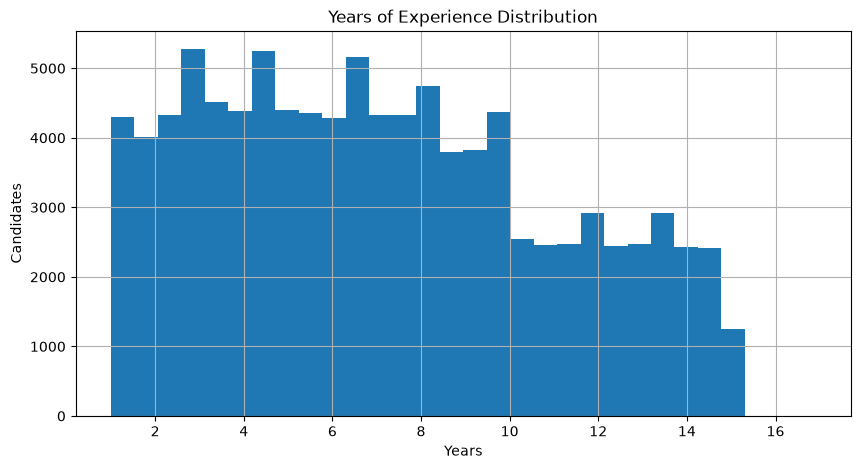

In [13]:
plt.figure(figsize=(10,5))

experience.hist(bins=30)

plt.title("Years of Experience Distribution")
plt.xlabel("Years")
plt.ylabel("Candidates")

plt.show()

In [14]:
industries = [
    c["profile"]["current_industry"]
    for c in candidates
]

industry_counts = (
    pd.Series(industries)
    .value_counts()
    .head(20)
)

industry_counts


IT Services          29881
Software             22417
Manufacturing        22305
Conglomerate          7571
Paper Products        7467
Fintech               2808
Food Delivery         2514
E-commerce            1529
Consulting            1274
EdTech                 610
SaaS                   328
AI/ML                  278
AdTech                 172
Transportation         162
Insurance Tech         155
Gaming                 149
HealthTech             147
HealthTech AI           68
Conversational AI       62
AI Services             42
Name: count, dtype: int64

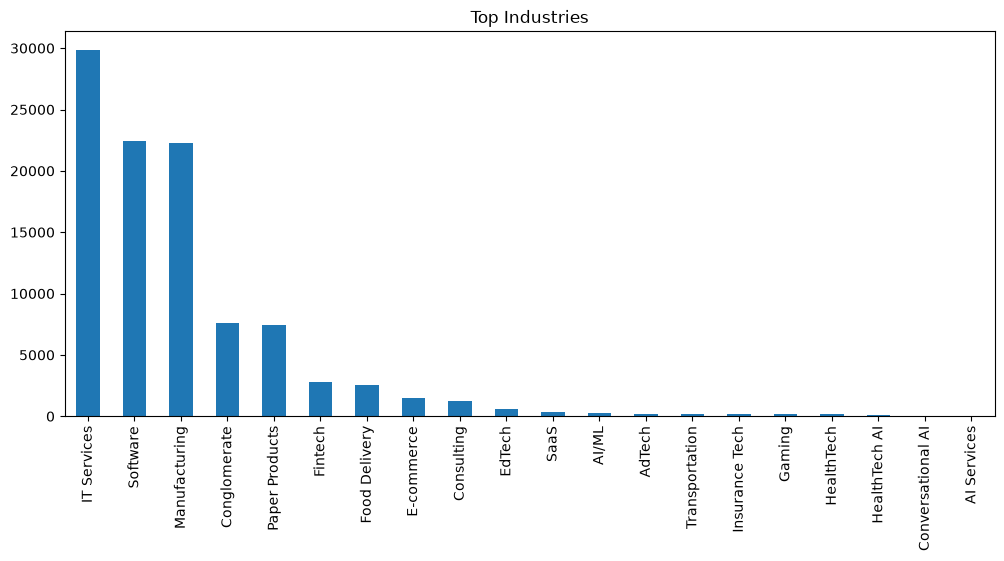

In [15]:
industry_counts.plot.bar(figsize=(12,5))

plt.title("Top Industries")

plt.show()

In [16]:
company_sizes = [
    c["profile"]["current_company_size"]
    for c in candidates
]

pd.Series(company_sizes).value_counts()

10001+        40464
1001-5000     18201
201-500       15096
51-200         7727
11-50          7568
501-1000       7525
5001-10000     3419
Name: count, dtype: int64

In [17]:
open_to_work = [
    c["redrob_signals"]["open_to_work_flag"]
    for c in candidates
]

pd.Series(open_to_work).value_counts()

False    64661
True     35339
Name: count, dtype: int64

In [18]:
pd.Series(open_to_work).value_counts(normalize=True) * 100


False    64.661
True     35.339
Name: proportion, dtype: float64

In [19]:
notice = [
    c["redrob_signals"]["notice_period_days"]
    for c in candidates
]

pd.Series(notice).describe()

count    100000.000000
mean         87.385800
std          36.589628
min           0.000000
25%          60.000000
50%          90.000000
75%         120.000000
max         150.000000
dtype: float64

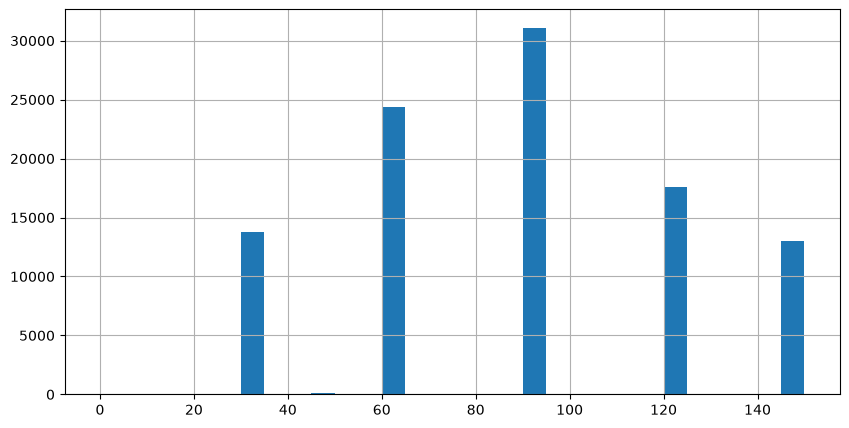

In [20]:
plt.figure(figsize=(10,5))

pd.Series(notice).hist(bins=30)

plt.show()

In [21]:
github = [
    c["redrob_signals"]["github_activity_score"]
    for c in candidates
]

github = pd.Series(github)

github.describe()

count    100000.000000
mean          9.619230
std          17.761394
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          16.700000
max          96.900000
dtype: float64

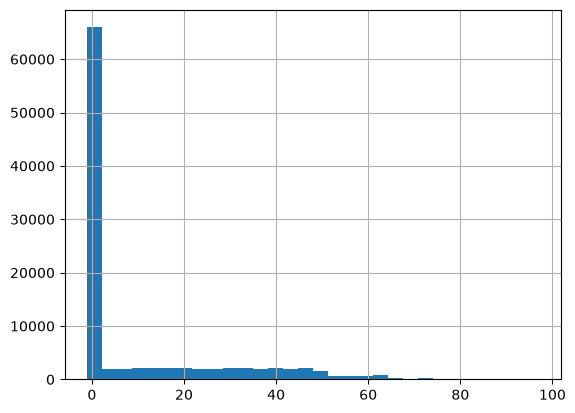

In [22]:
github.hist(bins=30)

plt.show()

In [23]:
response = [
    c["redrob_signals"]["recruiter_response_rate"]
    for c in candidates
]

pd.Series(response).describe()

count    100000.000000
mean          0.436574
std           0.214122
min           0.020000
25%           0.250000
50%           0.440000
75%           0.620000
max           0.950000
dtype: float64

In [24]:
missing_profile = Counter()

for c in candidates:

    for key, value in c["profile"].items():

        if value in ["", None]:

            missing_profile[key] += 1

missing_profile

Counter()